In [2]:
import pandas as pd
import numpy as np
import random
import math
import time
import psutil
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')


Evaluating Model: KNN
  Run 1: Acc=0.8485, Features=13
Features selected: [ 1  2  3  9 12 13 17 21 22 27 29 32 36]
  Run 2: Acc=0.8788, Features=14
Features selected: [ 1  6  8 12 13 17 18 20 22 24 28 30 32 34]
  Run 3: Acc=0.8939, Features=13
Features selected: [ 1  9 10 13 17 18 19 22 26 30 31 34 35]
  Run 4: Acc=0.8333, Features=13
Features selected: [ 7  9 10 11 13 17 18 21 22 23 32 34 35]
  Run 5: Acc=0.8788, Features=11
Features selected: [ 1  6  8 10 13 20 25 28 30 31 35]
  Run 6: Acc=0.8788, Features=10
Features selected: [ 0  1  2  9 12 13 16 18 24 29]
  Run 7: Acc=0.8788, Features=10
Features selected: [ 0  6 10 23 26 27 32 33 35 36]
  Run 8: Acc=0.8939, Features=15
Features selected: [ 0  1  4  7 12 13 15 16 17 18 21 23 24 32 34]
  Run 9: Acc=0.9091, Features=13
Features selected: [ 2  3  5 16 18 19 20 23 28 30 32 33 36]
  Run 10: Acc=0.8788, Features=12
Features selected: [ 0  1  2  3  7 14 15 18 19 27 34 36]
  Accuracy without FS  : 87.88 %

Evaluating Model: Naive Bayes


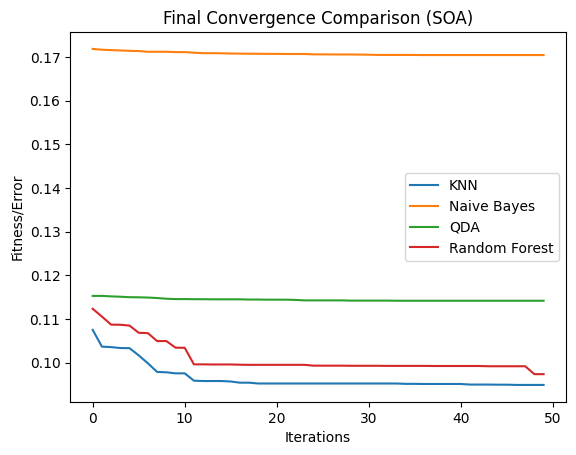


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 85.23 %
  Precision : 0.7804
  Recall    : 0.8523
  F1-Score  : 0.8135

  Avg Execution Time : 35.6826 s
  Avg Memory Used    : 0.1254 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  87.73%   0.8929  0.9776 0.9332      12.4    66.49%
  Naive Bayes  82.12%   0.9010  0.8948 0.8979       8.5    77.03%
          QDA  87.73%   0.8786  0.9983 0.9346       7.7    79.19%
Random Forest  87.88%   0.8788  1.0000 0.9355      14.6    60.54%


In [3]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-CM1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7791, Features=8
Features selected: [ 3  4  7  9 13 16 17 20]
  Run 2: Acc=0.7636, Features=10
Features selected: [ 3  5  7  8  9 10 13 14 17 20]
  Run 3: Acc=0.7733, Features=10
Features selected: [ 0  3  9 10 13 14 15 17 19 20]
  Run 4: Acc=0.7759, Features=12
Features selected: [ 0  3  4  6  8  9 10 11 13 17 18 19]
  Run 5: Acc=0.7701, Features=10
Features selected: [ 2  4  5  6  7 11 14 17 18 19]
  Run 6: Acc=0.7669, Features=7
Features selected: [ 1  3  7 13 16 17 20]
  Run 7: Acc=0.7771, Features=8
Features selected: [ 2 12 13 14 15 16 17 18]
  Run 8: Acc=0.7810, Features=12
Features selected: [ 0  3  4  9 10 11 12 13 14 15 16 20]
  Run 9: Acc=0.7714, Features=13
Features selected: [ 0  3  5  6  8  9 12 13 16 17 18 19 20]
  Run 10: Acc=0.7681, Features=7
Features selected: [ 2  8 11 12 15 18 19]
  Accuracy without FS  : 77.46 %

Evaluating Model: Naive Bayes
  Run 1: Acc=0.7861, Features=9
Features selected: [ 0  2  3  9 11 15 16 18 19]
  Run

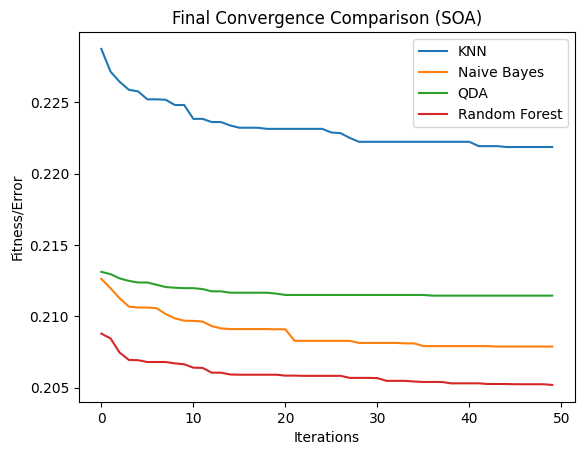


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 78.47 %
  Precision : 0.7564
  Recall    : 0.7847
  F1-Score  : 0.7314

  Avg Execution Time : 64.1141 s
  Avg Memory Used    : 0.1243 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  77.26%   0.8154  0.9181 0.8637       9.7    53.81%
  Naive Bayes  78.21%   0.8085  0.9467 0.8721       7.4    64.76%
          QDA  78.53%   0.7852  1.0000 0.8797       3.2    84.76%
Random Forest  79.29%   0.7995  0.9824 0.8816       7.6    63.81%


In [4]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-JM1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7426, Features=11
Features selected: [ 1  2  3  8 12 13 14 17 18 19 20]
  Run 2: Acc=0.7426, Features=10
Features selected: [ 2  3  5  8 11 15 16 17 19 20]
  Run 3: Acc=0.7342, Features=11
Features selected: [ 0  2  3  4  5  7  9 12 13 16 20]
  Run 4: Acc=0.7511, Features=12
Features selected: [ 1  2  3  5  7  8  9 10 11 13 15 20]
  Run 5: Acc=0.6878, Features=7
Features selected: [ 5  8 10 11 13 14 19]
  Run 6: Acc=0.7089, Features=11
Features selected: [ 0  2  3  5  7  9 10 13 14 15 17]
  Run 7: Acc=0.7468, Features=7
Features selected: [ 1  3  9 11 12 16 20]
  Run 8: Acc=0.7215, Features=11
Features selected: [ 2  5  7  8 12 13 15 16 17 19 20]
  Run 9: Acc=0.7384, Features=12
Features selected: [ 0  1  2  3  7  8  9 10 12 13 17 20]
  Run 10: Acc=0.7300, Features=13
Features selected: [ 0  2  5  7  8 10 12 13 16 17 18 19 20]
  Accuracy without FS  : 70.89 %

Evaluating Model: Naive Bayes
  Run 1: Acc=0.7300, Features=6
Features selected: [ 3 10 1

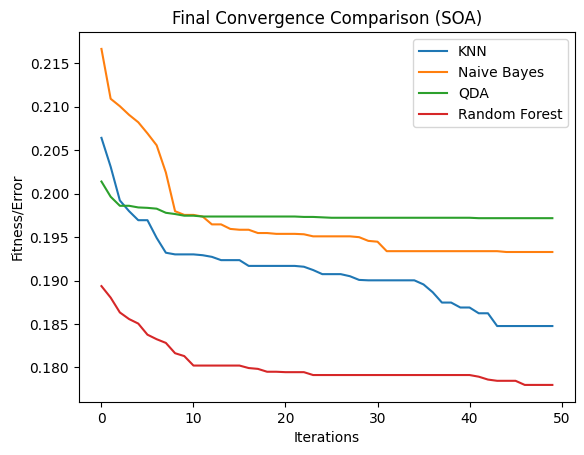


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 72.05 %
  Precision : 0.6798
  Recall    : 0.7205
  F1-Score  : 0.6785

  Avg Execution Time : 44.3819 s
  Avg Memory Used    : 0.0090 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  73.04%   0.7754  0.8908 0.8291      10.5    50.00%
  Naive Bayes  71.35%   0.7576  0.8966 0.8212       6.5    69.05%
          QDA  72.15%   0.7362  0.9672 0.8361       9.2    56.19%
Random Forest  74.39%   0.7632  0.9443 0.8441      10.5    50.00%


In [5]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-KC1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7692, Features=14
Features selected: [14 15 17 19 21 22 24 26 27 28 33 34 37 38]
  Run 2: Acc=0.7949, Features=16
Features selected: [ 0 10 11 12 14 19 20 21 22 24 25 30 33 34 35 38]
  Run 3: Acc=0.7949, Features=13
Features selected: [ 6 13 14 18 20 21 23 25 26 28 33 35 38]
  Run 4: Acc=0.7692, Features=18
Features selected: [ 1  2  7  8  9 10 11 14 19 21 22 23 24 27 29 32 34 37]
  Run 5: Acc=0.7692, Features=18
Features selected: [ 2  6  8  9 11 13 19 20 21 22 24 27 28 30 31 34 36 37]
  Run 6: Acc=0.8974, Features=16
Features selected: [ 0  3  9 10 14 21 22 24 26 27 30 31 33 34 35 36]
  Run 7: Acc=0.7692, Features=19
Features selected: [ 0  1  5  9 11 13 17 19 20 21 27 29 30 32 33 34 35 37 38]
  Run 8: Acc=0.8718, Features=20
Features selected: [ 0  1  3  5  6 13 14 15 17 19 23 24 27 30 31 32 34 35 36 38]
  Run 9: Acc=0.7692, Features=21
Features selected: [ 5  8 11 13 15 18 19 20 21 22 23 24 25 27 28 29 31 33 34 37 38]
  Run 10: Acc=0.7949, Feat

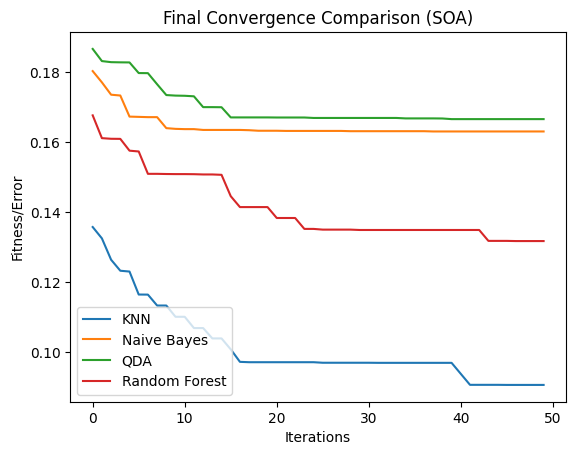


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 79.49 %
  Precision : 0.7429
  Recall    : 0.7949
  F1-Score  : 0.7503

  Avg Execution Time : 33.9257 s
  Avg Memory Used    : 0.1437 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  80.00%   0.8310  0.9500 0.8863      17.1    56.15%
  Naive Bayes  80.51%   0.8514  0.9250 0.8863      13.1    66.41%
          QDA  82.05%   0.8378  0.9688 0.8986      14.4    63.08%
Random Forest  81.79%   0.8286  0.9812 0.8984      15.5    60.26%


In [3]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-KC3.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9724, Features=15
Features selected: [ 1  2  8 11 12 14 15 17 19 27 29 31 32 35 37]
  Run 2: Acc=0.9749, Features=17
Features selected: [ 0  1  2  3  4  6  8 11 20 22 24 26 27 29 30 31 32]
  Run 3: Acc=0.9698, Features=11
Features selected: [ 2  6 12 15 19 20 23 31 33 35 37]
  Run 4: Acc=0.9774, Features=12
Features selected: [ 3 10 18 19 21 23 25 26 29 30 33 35]
  Run 5: Acc=0.9799, Features=15
Features selected: [ 0  7  8 13 15 17 19 20 23 24 25 26 29 34 35]
  Run 6: Acc=0.9774, Features=12
Features selected: [ 6  7  8 15 17 20 21 23 24 29 31 37]
  Run 7: Acc=0.9774, Features=12
Features selected: [ 0  2  3  7  9 14 16 17 22 23 24 37]
  Run 8: Acc=0.9724, Features=13
Features selected: [ 2  8  9 10 11 12 15 17 22 25 29 31 33]
  Run 9: Acc=0.9749, Features=12
Features selected: [ 0  2  7  9 10 15 17 19 21 27 33 36]
  Run 10: Acc=0.9749, Features=11
Features selected: [ 5  7 10 12 14 17 20 24 25 28 29]
  Accuracy without FS  : 97.99 %

Evaluating M

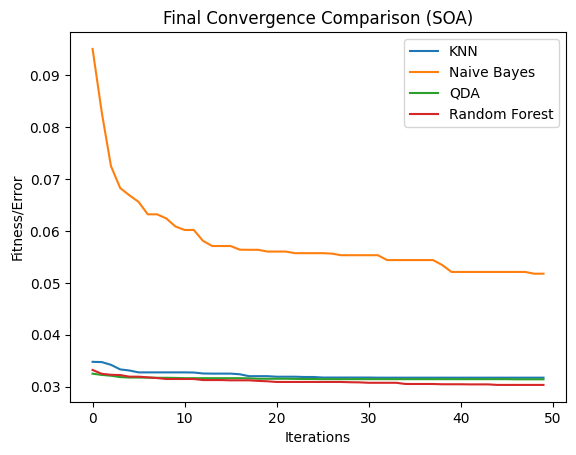


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 96.04 %
  Precision : 0.9611
  Recall    : 0.9604
  F1-Score  : 0.9585

  Avg Execution Time : 53.3698 s
  Avg Memory Used    : 0.0664 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  97.51%   0.9785  0.9964 0.9874      13.0    65.79%
  Naive Bayes  94.70%   0.9774  0.9681 0.9727      12.1    68.16%
          QDA  97.74%   0.9774  1.0000 0.9886      13.0    65.79%
Random Forest  97.74%   0.9774  1.0000 0.9886      14.8    61.05%


In [4]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MC1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.6800, Features=11
Features selected: [ 1  2 16 18 23 27 28 30 31 33 38]
  Run 2: Acc=0.5600, Features=20
Features selected: [ 4  5  6  8  9 11 12 13 14 15 18 20 21 22 23 33 34 36 37 38]
  Run 3: Acc=0.6000, Features=17
Features selected: [ 1  5  9 11 12 16 17 18 19 20 22 25 27 30 31 35 36]
  Run 4: Acc=0.6000, Features=18
Features selected: [ 1  4  6  7  9 11 14 15 16 18 19 20 21 24 29 30 31 36]
  Run 5: Acc=0.6000, Features=14
Features selected: [ 0  5  8 10 12 14 15 19 20 21 22 23 27 32]
  Run 6: Acc=0.6800, Features=22
Features selected: [ 0  1  5  8  9 11 12 15 18 20 21 22 23 24 25 27 28 29 31 32 35 38]
  Run 7: Acc=0.7600, Features=14
Features selected: [ 2  4  6 11 12 17 19 20 23 29 30 31 33 37]
  Run 8: Acc=0.6400, Features=15
Features selected: [ 6  7  9 14 15 16 18 21 22 27 29 31 33 34 36]
  Run 9: Acc=0.6400, Features=19
Features selected: [ 0  1  2  5  6  7  8  9 11 13 18 20 21 23 27 28 34 36 37]
  Run 10: Acc=0.6400, Features=25
Feature

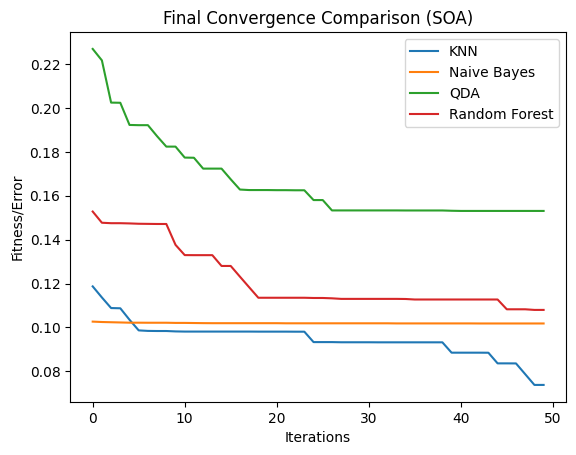


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 72.00 %
  Precision : 0.7489
  Recall    : 0.7200
  F1-Score  : 0.6707

  Avg Execution Time : 32.4328 s
  Avg Memory Used    : 0.0090 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  64.00%   0.6786  0.8375 0.7480      17.5    55.13%
  Naive Bayes  78.40%   0.7737  0.9375 0.8476      10.9    72.05%
          QDA  71.20%   0.7042  0.9500 0.8087      17.9    54.10%
Random Forest  75.20%   0.7381  0.9500 0.8306      15.7    59.74%


In [5]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MC2.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9216, Features=17
Features selected: [ 0  2  4  6  9 12 13 15 19 21 23 25 27 28 31 33 36]
  Run 2: Acc=0.8824, Features=9
Features selected: [ 2  9 10 13 18 27 31 32 33]
  Run 3: Acc=0.9020, Features=17
Features selected: [ 0  1  2  3  5  9 10 12 23 24 25 28 29 30 31 33 35]
  Run 4: Acc=0.9020, Features=14
Features selected: [ 2  6  7  8 11 12 19 22 23 25 27 28 29 33]
  Run 5: Acc=0.9216, Features=16
Features selected: [ 1  6  8 10 12 13 14 19 20 21 24 28 29 31 32 33]
  Run 6: Acc=0.8627, Features=13
Features selected: [ 2  6  7  8 10 15 24 25 26 28 29 31 32]
  Run 7: Acc=0.9216, Features=14
Features selected: [ 2  3  6  9 10 11 13 14 22 23 24 28 32 33]
  Run 8: Acc=0.8824, Features=15
Features selected: [ 2  3  4  8 10 12 13 18 19 22 24 25 28 29 32]
  Run 9: Acc=0.8824, Features=16
Features selected: [ 2  5  7  9 10 11 14 18 19 22 23 25 26 28 29 32]
  Run 10: Acc=0.9216, Features=12
Features selected: [ 2  3  6  7 12 14 19 25 26 29 32 33]
  Accura

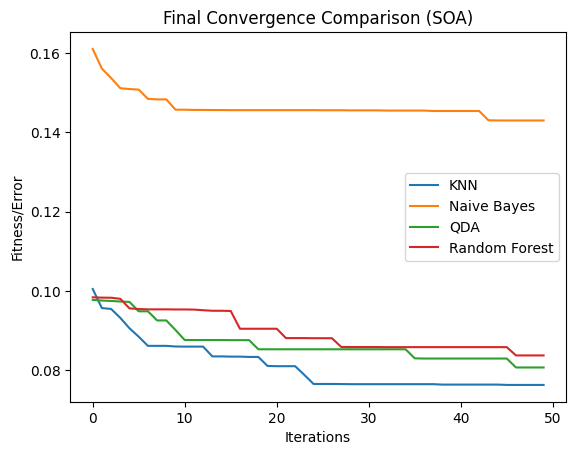


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 83.82 %
  Precision : 0.8506
  Recall    : 0.8382
  F1-Score  : 0.8340

  Avg Execution Time : 31.4379 s
  Avg Memory Used    : 0.0028 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  90.00%   0.9253  0.9674 0.9457      14.3    61.35%
  Naive Bayes  79.80%   0.9280  0.8413 0.8824      10.8    70.81%
          QDA  89.80%   0.9032  0.9935 0.9462      12.7    65.68%
Random Forest  89.41%   0.9196  0.9674 0.9427      15.0    59.46%


In [6]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MW1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8865, Features=13
Features selected: [ 0  4  7  8 10 13 18 20 30 31 32 35 36]
  Run 2: Acc=0.9007, Features=13
Features selected: [ 0  3  4 12 13 15 16 23 28 30 34 35 36]
  Run 3: Acc=0.9149, Features=17
Features selected: [ 0  1  4  5  7  9 13 15 16 19 22 26 27 30 32 33 34]
  Run 4: Acc=0.9078, Features=13
Features selected: [ 0  1  4 11 12 13 14 15 22 24 27 29 33]
  Run 5: Acc=0.9078, Features=18
Features selected: [ 3  4  5  7  8 10 12 13 15 16 19 22 23 31 32 33 34 35]
  Run 6: Acc=0.9291, Features=21
Features selected: [ 3  5  6  7  8  9 10 13 15 16 19 20 21 23 26 27 29 31 32 33 34]
  Run 7: Acc=0.9149, Features=19
Features selected: [ 0  1  3  5  7  9 12 15 16 17 19 20 22 27 28 29 32 35 36]
  Run 8: Acc=0.9078, Features=14
Features selected: [ 0  2  4 12 15 17 20 21 22 26 29 30 32 33]
  Run 9: Acc=0.9007, Features=19
Features selected: [ 7  8 10 11 12 15 16 18 20 22 24 28 30 31 32 33 34 35 36]
  Run 10: Acc=0.8794, Features=10
Features selecte

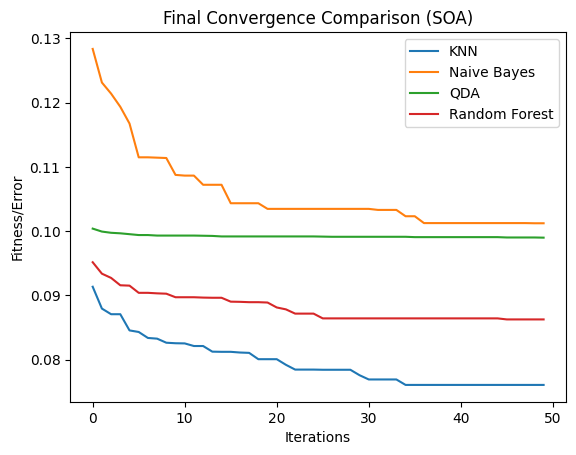


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 89.01 %
  Precision : 0.8497
  Recall    : 0.8901
  F1-Score  : 0.8689

  Avg Execution Time : 29.2088 s
  Avg Memory Used    : 0.0002 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  90.50%   0.9238  0.9767 0.9495      15.7    57.57%
  Naive Bayes  88.51%   0.9248  0.9519 0.9381      11.5    68.92%
          QDA  91.49%   0.9149  1.0000 0.9556       9.7    73.78%
Random Forest  90.50%   0.9183  0.9837 0.9499      14.5    60.81%


In [7]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC1.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9799, Features=16
Features selected: [ 0  1  3  7  9 13 14 22 25 27 28 29 30 33 34 35]
  Run 2: Acc=0.9732, Features=8
Features selected: [ 2  8 13 19 20 23 31 33]
  Run 3: Acc=0.9799, Features=8
Features selected: [ 3  4  6 16 17 19 23 31]
  Run 4: Acc=0.9799, Features=9
Features selected: [ 0  1 10 11 13 19 22 27 28]
  Run 5: Acc=0.9799, Features=9
Features selected: [ 0 11 14 19 20 25 30 32 33]
  Run 6: Acc=0.9799, Features=9
Features selected: [ 0  1  5  8 11 19 22 27 34]
  Run 7: Acc=0.9732, Features=9
Features selected: [ 1  3 12 14 28 29 33 34 35]
  Run 8: Acc=0.9732, Features=12
Features selected: [ 0  1  3  5  7  9 14 19 20 22 26 34]
  Run 9: Acc=0.9799, Features=9
Features selected: [ 4  6 10 11 12 20 27 30 31]
  Run 10: Acc=0.9799, Features=9
Features selected: [ 8 10 12 17 18 26 27 30 35]
  Accuracy without FS  : 97.99 %

Evaluating Model: Naive Bayes
  Run 1: Acc=0.9396, Features=13
Features selected: [ 0  2  4  5  7  9 14 15 20 21 22 

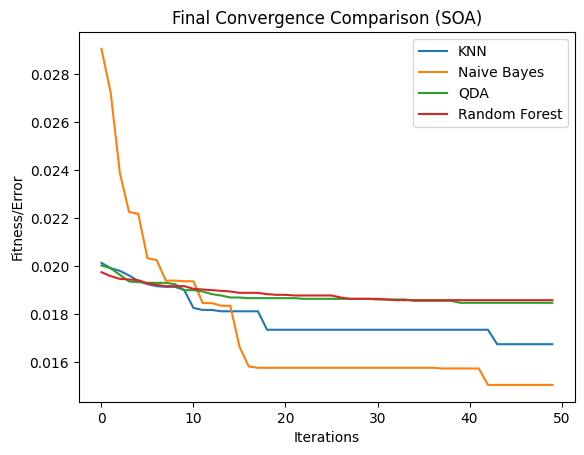


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 95.81 %
  Precision : 0.9617
  Recall    : 0.9581
  F1-Score  : 0.9590

  Avg Execution Time : 29.4139 s
  Avg Memory Used    : 0.0075 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  97.79%   0.9798  0.9979 0.9888       9.8    72.78%
  Naive Bayes  93.09%   0.9857  0.9432 0.9639      12.6    65.00%
          QDA  97.99%   0.9799  1.0000 0.9898       7.1    80.28%
Random Forest  97.99%   0.9799  1.0000 0.9898       7.5    79.17%


In [8]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC2.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8843, Features=15
Features selected: [ 1  2  5  6  8 11 12 15 17 18 22 28 31 34 35]
  Run 2: Acc=0.8472, Features=14
Features selected: [ 0  1  2  3  4  5  6 16 17 18 19 20 29 35]
  Run 3: Acc=0.8843, Features=16
Features selected: [ 1  2  3  4  7  8 10 11 13 15 18 19 22 28 32 35]
  Run 4: Acc=0.9074, Features=11
Features selected: [ 5  6 15 17 19 23 24 32 34 35 36]
  Run 5: Acc=0.8750, Features=16
Features selected: [ 0  2  4  7  8 11 15 17 19 20 22 23 24 31 33 35]
  Run 6: Acc=0.8843, Features=21
Features selected: [ 1  4  6  7  8 10 11 12 16 18 21 24 25 26 27 28 29 30 32 33 36]
  Run 7: Acc=0.8796, Features=16
Features selected: [ 0  1  2  3  4  5 11 16 22 24 27 30 31 32 33 35]
  Run 8: Acc=0.8704, Features=21
Features selected: [ 0  2  4  5  6 10 11 15 16 17 19 20 21 23 26 27 28 30 31 33 34]
  Run 9: Acc=0.8843, Features=13
Features selected: [ 0  2  4  8 11 16 20 22 23 26 27 28 30]
  Run 10: Acc=0.8657, Features=17
Features selected: [ 2  3  4

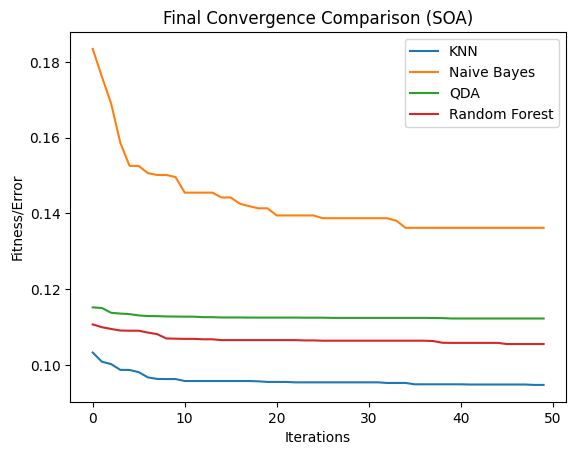


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 70.72 %
  Precision : 0.7980
  Recall    : 0.7072
  F1-Score  : 0.6712

  Avg Execution Time : 40.9126 s
  Avg Memory Used    : 0.0153 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  87.82%   0.8937  0.9772 0.9335      16.0    56.76%
  Naive Bayes  74.72%   0.9430  0.7582 0.8328      10.6    71.35%
          QDA  87.31%   0.8748  0.9979 0.9323      13.1    64.59%
Random Forest  87.41%   0.8763  0.9968 0.9327      15.7    57.57%


In [9]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC3.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8953, Features=19
Features selected: [ 2  3  4  5  6  7  8  9 19 22 23 24 25 26 29 30 31 34 36]
  Run 2: Acc=0.8953, Features=15
Features selected: [ 2  3  4  7  9 12 14 22 23 24 25 26 28 30 36]
  Run 3: Acc=0.8953, Features=17
Features selected: [ 2  3  4  5 13 15 19 21 23 24 25 27 29 31 32 34 36]
  Run 4: Acc=0.8915, Features=18
Features selected: [ 0  1  2  3  7  8  9 10 13 18 19 21 23 25 28 29 34 36]
  Run 5: Acc=0.8992, Features=14
Features selected: [ 2  3  4  5 15 17 23 24 25 27 28 31 34 36]
  Run 6: Acc=0.8876, Features=17
Features selected: [ 0  2  3  5  6  7 15 16 18 20 22 23 25 27 29 34 36]
  Run 7: Acc=0.8915, Features=20
Features selected: [ 0  1  2  3  5  6  7  8  9 10 14 15 20 21 23 24 27 32 34 36]
  Run 8: Acc=0.8798, Features=20
Features selected: [ 1  2  3  4  6  7  8 12 13 14 17 19 20 22 23 25 28 31 34 36]
  Run 9: Acc=0.8915, Features=19
Features selected: [ 1  2  3  4  6  7  8  9 10 13 14 20 22 24 25 27 32 34 36]
  Run 10: Acc=

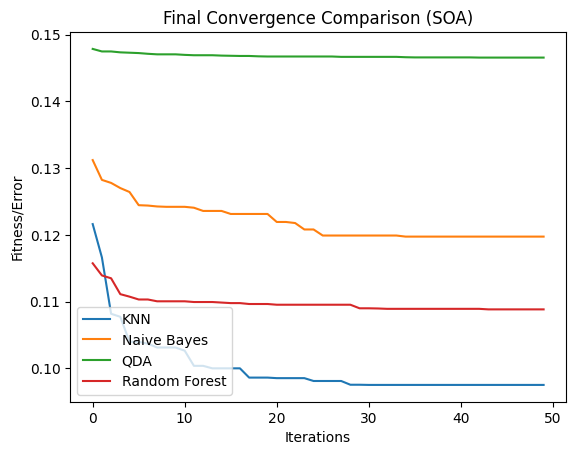


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 86.92 %
  Precision : 0.8291
  Recall    : 0.8692
  F1-Score  : 0.8373

  Avg Execution Time : 48.9336 s
  Avg Memory Used    : 0.0063 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  89.26%   0.9172  0.9628 0.9394      17.7    52.16%
  Naive Bayes  88.33%   0.9112  0.9587 0.9342      16.3    55.95%
          QDA  86.43%   0.8643  1.0000 0.9272       8.8    76.22%
Random Forest  89.22%   0.8926  0.9951 0.9411      15.1    59.19%


In [10]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC4.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7697, Features=17
Features selected: [ 3  5  8  9 11 12 13 15 20 21 22 23 25 27 30 35 37]
  Run 2: Acc=0.7726, Features=21
Features selected: [ 1  2  3  4  5  7  8 11 12 13 14 16 20 21 22 24 25 31 33 35 37]
  Run 3: Acc=0.7551, Features=19
Features selected: [ 1  3  4  5  6 10 16 17 18 20 23 25 27 29 30 31 32 35 37]
  Run 4: Acc=0.7522, Features=17
Features selected: [ 1  5  6  9 11 12 13 15 17 18 23 24 28 29 30 32 37]
  Run 5: Acc=0.7872, Features=21
Features selected: [ 2  3  4  6  7  9 11 12 14 15 16 18 21 22 24 25 28 29 32 35 37]
  Run 6: Acc=0.7493, Features=17
Features selected: [ 2  3  4  5  6  7  8 11 15 16 20 21 24 29 34 35 37]
  Run 7: Acc=0.7755, Features=17
Features selected: [ 2  5 10 11 12 15 16 17 19 21 24 25 30 33 34 35 37]
  Run 8: Acc=0.7318, Features=17
Features selected: [ 3  4  7  8 14 15 16 17 19 20 21 22 23 25 27 29 32]
  Run 9: Acc=0.7901, Features=21
Features selected: [ 0  1  2  3  5  6  8 11 12 13 14 15 16 18 20 22 23 25 

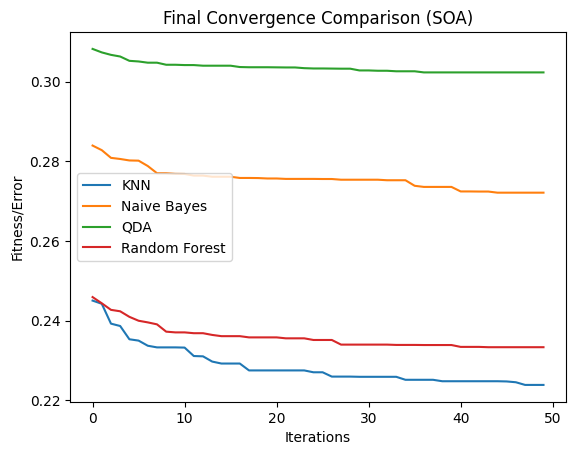


  SUMMARY  (averaged over 10 independent runs)

  Accuracy  : 74.64 %
  Precision : 0.7172
  Recall    : 0.7464
  F1-Score  : 0.7013

  Avg Execution Time : 46.7906 s
  Avg Memory Used    : 0.0152 MB

        Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
          KNN  76.27%   0.8058  0.8871 0.8444      18.6    51.05%
  Naive Bayes  72.83%   0.7592  0.9165 0.8304      16.6    56.32%
          QDA  73.47%   0.7333  0.9972 0.8451      14.6    61.58%
Random Forest  75.28%   0.7659  0.9498 0.8480      17.5    53.95%


In [11]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ================================
# DATA LOADING & PREPROCESSING
# ================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC5.csv')
df = df.drop(columns=['id'], errors='ignore')

target_col = df.columns[-1]

df[target_col] = df[target_col].astype(str).str.strip().str.upper()
label_mapped = df[target_col].map({'Y': 0,'N': 1})
label = label_mapped.fillna(0).astype(int).values

feat_df = df.drop(columns=[target_col, 'id', 'name'], errors='ignore')
feat_df = feat_df.apply(pd.to_numeric, errors='coerce').fillna(0)
feat = feat_df.values

train_idx, test_idx = train_test_split(
    np.arange(len(label)), test_size=0.2, random_state=42, stratify=label
)

scaler = MinMaxScaler()
feat[train_idx] = scaler.fit_transform(feat[train_idx])
feat[test_idx] = scaler.transform(feat[test_idx])

# ================================
# UTILITIES
# ================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _mutation__(current_pos, new_pos, dim, ratio):
    mask = np.random.uniform(0, 1, dim) < ratio
    return np.where(mask, current_pos, new_pos)

def jInitialPopulation(N, dim):
    return np.random.randint(0, 2, (N, dim))

def jGenericWrapper(sFeat, label, train_idx, test_idx, model_obj):
    y_train, y_test = label[train_idx], label[test_idx]
    if len(np.unique(y_train)) < 2:
        return 1.0
    try:
        model_obj.fit(sFeat[train_idx], y_train)
        pred = model_obj.predict(sFeat[test_idx])
        return 1 - accuracy_score(y_test, pred)
    except:
        return 1.0

def jFitnessFunction(feat, label, X, train_idx, test_idx, model_obj):
    train_idx2, valid_idx = train_test_split(
        np.arange(len(label[train_idx])),
        test_size=0.2,
        random_state=42,
        stratify=label[train_idx]
    )
    alpha, beta = 0.99, 0.01

    if np.sum(X) == 0:
        return np.inf

    selected = feat[:, X == 1]
    error = jGenericWrapper(selected, label, train_idx2, valid_idx, model_obj)

    return alpha * error + beta * (np.sum(X) / feat.shape[1])

def Levy(dim):
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
            (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = 0.01 * np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.power(np.abs(v), (1 / beta))

# ================================
# SOA
# ================================
def SOA_SFP(feat, label, train_idx, test_idx, model_obj, PopSize=10, iters=50):

    dim = feat.shape[1]
    X = jInitialPopulation(PopSize, dim)
    Cost = np.array([jFitnessFunction(feat, label, X[i], train_idx, test_idx, model_obj) for i in range(PopSize)])

    Best_X = X[np.argmin(Cost)].copy()
    Best_Cost = np.min(Cost)
    convergence = []

    for l in range(iters):
        A = np.exp(-4 * l / iters)
        mut_ratio = 0.5 * (1 - l / iters)

        for i in range(PopSize):
            ids = [idx for idx in range(PopSize) if idx != i]
            id1, id2 = random.sample(ids, 2)

            dfXbest = (Best_Cost - Cost[i]) / (2 * random.random() + 1e-10)
            dfX = (jFitnessFunction(feat, label, X[id1], train_idx, test_idx, model_obj) - Cost[i]) / (2 * random.random() + 1e-10)

            velocity = A * (dfXbest * (X[i] - Best_X)) / (dfX - dfXbest + 1e-10)

            Xnew = X[i].copy()

            for d in range(dim):
                if random.random() < sigmoid(velocity[d]):
                    Xnew[d] = 1 - X[i, d]

            if random.random() < 0.5:
                Z = Levy(dim)
                v_leo = Best_X + Z * (Xnew - X[i])
                for d in range(dim):
                    if random.random() < sigmoid(v_leo[d]):
                        Xnew[d] = 1 - X[i, d]

            Xnew = _mutation__(X[i], Xnew, dim, mut_ratio)

            Xnew_Cost = jFitnessFunction(feat, label, Xnew, train_idx, test_idx, model_obj)

            if Xnew_Cost < Cost[i]:
                Cost[i], X[i] = Xnew_Cost, Xnew.copy()

                if Xnew_Cost < Best_Cost:
                    Best_Cost, Best_X = Xnew_Cost, X[i].copy()

        convergence.append(Best_Cost)

    return convergence, Best_X

# ================================
# MAIN
# ================================
models_to_test = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS = []
average_precision_without_FS = []
average_recall_without_FS = []
average_f1_without_FS = []

for model_name, model_obj in models_to_test.items():

    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        conv, best_sol = SOA_SFP(feat, label, train_idx, test_idx, model_obj)

        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_sol == 1)[0]

        clf = clone(model_obj)
        clf.fit(feat[train_idx][:, Sf_idx], label[train_idx])
        pred = clf.predict(feat[test_idx][:, Sf_idx])
        y_true = label[test_idx]

        acc_list.append(np.mean(pred == y_true))
        prec_list.append(precision_score(y_true, pred, zero_division=0))
        rec_list.append(recall_score(y_true, pred, zero_division=0))
        f1_list.append(f1_score(y_true, pred, zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(conv)

        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f"Features selected: {Sf_idx}")

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/feat.shape[1]))*100:.2f}%"
    })

    clf_nofs = clone(model_obj)
    clf_nofs.fit(feat[train_idx], label[train_idx])
    pred_no_fs = clf_nofs.predict(feat[test_idx])

    acc_no_fs = np.mean(pred_no_fs == label[test_idx]) * 100
    print(f"  Accuracy without FS  : {acc_no_fs:.2f} %")

    average_accuracy_without_FS.append(acc_no_fs)
    average_precision_without_FS.append(precision_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(label[test_idx], pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (SOA)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)